In [148]:
with open("/content/drive/MyDrive/Ciencia De Datos/Cuento.txt", "r", encoding="utf-8") as archivo:
  discurso = archivo.read()

In [149]:
print(discurso[:500])

En una tierra muy lejana, una princesa disfrutaba de la brisa fresca de la tarde afuera del palacio de su familia. Ella llevaba consigo una pequeña bola dorada que era su posesión más preciada. Mientras jugaba, la arrojó tan alto que perdió vista de ella y la bola rodó hacia un estanque. La princesa comenzó a llorar desconsoladamente. Entonces, una pequeña rana salió del estanque saltando.

—¿Qué pasa bella princesa? —preguntó la rana.

La princesa se enjugó las lágrimas y dijo:

—Mi bola dorada


In [150]:
len(discurso)

2443

In [172]:
discurso = discurso.lower()
discurso = discurso.replace(",", "")
discurso = discurso.replace(";", "")
discurso = discurso.replace(".", "")
discurso = discurso.replace(":", "")
discurso = discurso.replace("-", "")
discurso = discurso.replace("—", "")
len(discurso)

2379

In [173]:
palabras = discurso.split()
print(palabras[:20])

['en', 'una', 'tierra', 'muy', 'lejana', 'una', 'princesa', 'disfrutaba', 'de', 'la', 'brisa', 'fresca', 'de', 'la', 'tarde', 'afuera', 'del', 'palacio', 'de', 'su']


In [174]:
import pandas as pd
import numpy as np

palabras_array = np.array(palabras)

In [175]:
len(palabras_array)

434

In [176]:
longitudes = np.array([len(palabra) for palabra in palabras_array])

In [177]:
print("Promedio",np.mean(longitudes))
print("Mediana",np.median(longitudes))
print("Minimo",np.min(longitudes))
print("Maximo",np.max(longitudes))

Promedio 4.444700460829493
Mediana 4.0
Minimo 1
Maximo 17


In [178]:
df = pd.DataFrame(
    {
        "palabra": palabras_array,
        "longitud": longitudes.ravel()
    }
)
df.head(10)

,palabra,longitud
0,en,2
1,una,3
2,tierra,6
3,muy,3
4,lejana,6
5,una,3
6,princesa,8
7,disfrutaba,10
8,de,2
9,la,2


In [179]:
frecuencias = df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
la          45
de          22
rana        17
y           16
princesa    15
una         10
que          9
su           8
en           8
a            8
un           7
se           7
el           6
bola         5
del          5
le           5
al           5
estanque     4
dijo         4
palacio      3
Name: count, dtype: int64


In [185]:
stopwords = [
    "la", "de", "y", "una", "que","a", "en", "su", "un", "se", "el", "le",
    "del", "al", "ella", "me", "muy", "para", "me", "mis", "no", "pero", "solo",
    "era", "con", "he", "lo", "mi", "si", "tan", "las", "qué", "como", "más", "por",
]

In [186]:
df_limpio = df[~df["palabra"].isin(stopwords)]

In [190]:
frecuencias = df_limpio["palabra"].value_counts()
print(frecuencias.head(50))

palabra
rana                 17
princesa             15
bola                  5
estanque              4
dijo                  4
dorada                3
palacio               3
beso                  3
promesa               3
habitación            3
plato                 3
hacia                 2
pequeña               2
entonces              2
dejar                 2
exclamó               2
había                 2
ahora                 2
siempre               2
príncipe              2
posesión              1
disfrutaba            1
llevaba               1
consigo               1
afuera                1
familia               1
arrojó                1
comenzó               1
rodó                  1
desconsoladamente     1
jugaba                1
llorar                1
salió                 1
pasa                  1
saltando              1
bella                 1
preguntó              1
mientras              1
preciada              1
vista                 1
perdió                1
alto    

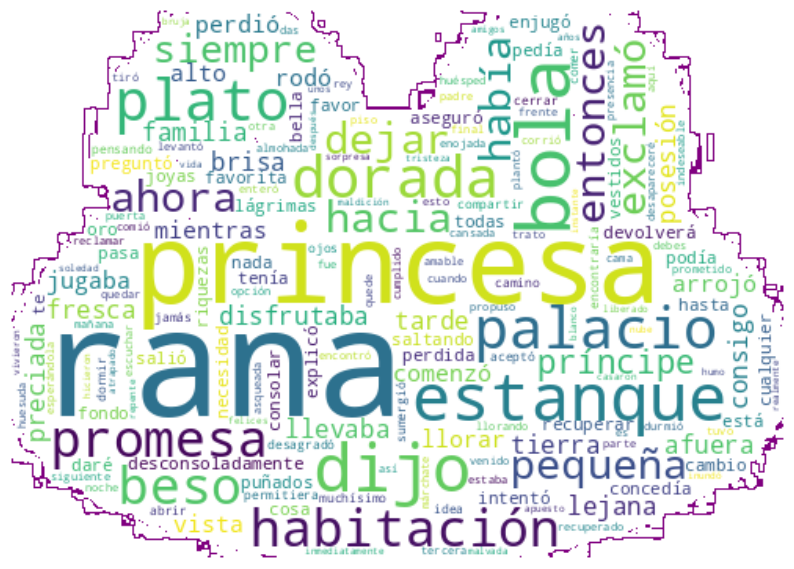

In [209]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

mask_image = np.array(Image.open("/content/drive/MyDrive/Ciencia De Datos/Ranita.jpg"))

texto_limpio = " ".join(df_limpio["palabra"])

nube = WordCloud(
    background_color="white",
    mask=mask_image,
    contour_width=1,
    contour_color="purple"
).generate(texto_limpio)

plt.figure(figsize=(10, 10))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()